# Experiment 8: Clustering Human Activity Recognition Data

## Objective
To implement and analyze the performance of clustering algorithms on the Human Activity Recognition dataset:
- K-Means Clustering
- DBSCAN
- Hierarchical Agglomerative Clustering (HAC)




In [12]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore')



## 1. Preprocessing Steps




In [13]:
# Load dataset
import pandas as pd
base_dir = 'dataset/dataset'
X_train = pd.read_csv(f'{base_dir}/train/X_train.txt', sep=r'\s+', header=None)
y_train = pd.read_csv(f'{base_dir}/train/y_train.txt', sep=r'\s+', header=None)
X_test = pd.read_csv(f'{base_dir}/test/X_test.txt', sep=r'\s+', header=None)
y_test = pd.read_csv(f'{base_dir}/test/y_test.txt', sep=r'\s+', header=None)

X = pd.concat([X_train, X_test], ignore_index=True)
y_true = pd.concat([y_train, y_test], ignore_index=True)[0]

# Map activity labels
activity_labels = pd.read_csv(f'{base_dir}/activity_labels.txt', sep=r'\s+', header=None, index_col=0)[1].to_dict()
df = X.copy()
df['Activity'] = y_true.map(activity_labels)

# Encode categorical labels
le = LabelEncoder()
y_encoded = le.fit_transform(df['Activity'])
y_true = df['Activity']

# Apply normalization/standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape: {X_scaled.shape}")


Dataset shape: (10299, 561)


## 2. Exploratory Data Analysis (EDA)




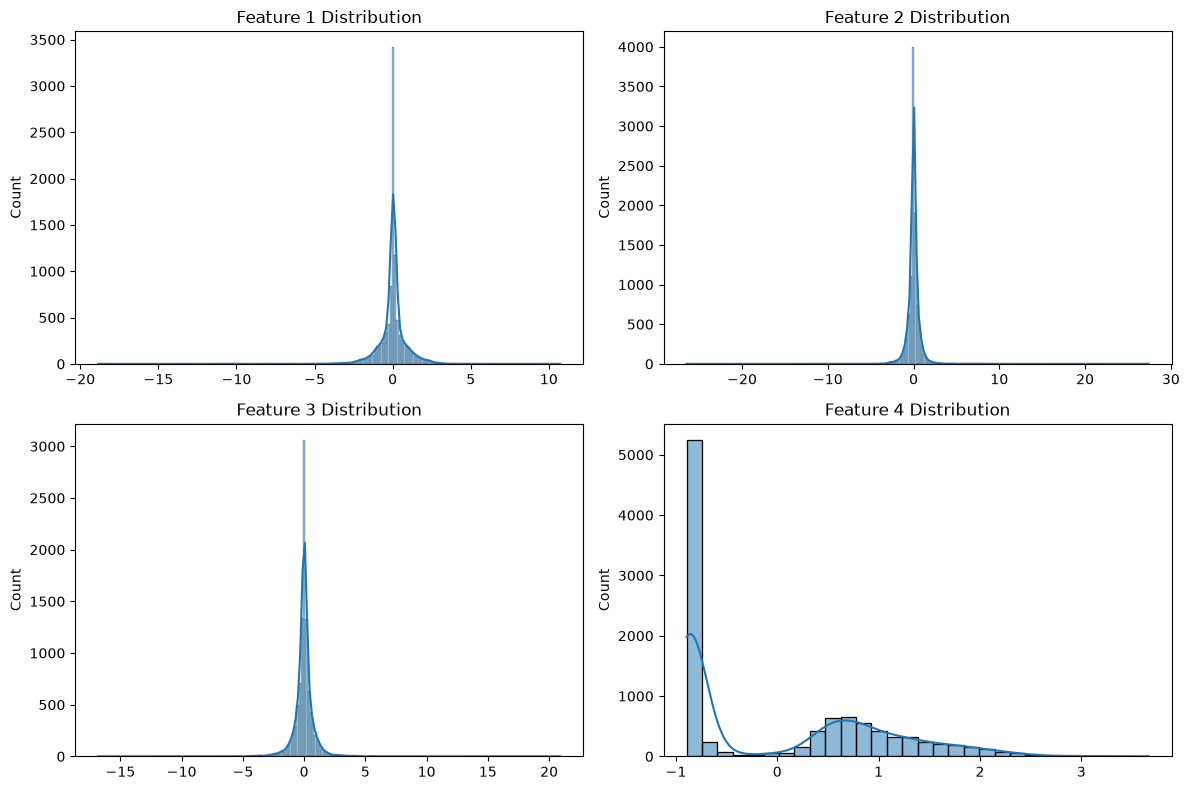

In [14]:
# Visualize feature distributions (sample 4 features)
plt.figure(figsize=(12, 8))
for i in range(min(4, X_scaled.shape[1])):
    plt.subplot(2, 2, i+1)
    sns.histplot(X_scaled[:, i], kde=True)
    plt.title(f'Feature {i+1} Distribution')
plt.tight_layout()
import os; os.makedirs('./images', exist_ok=True)
plt.savefig('./images/exp8_plot_1.pdf', format='pdf', bbox_inches='tight')
plt.show()



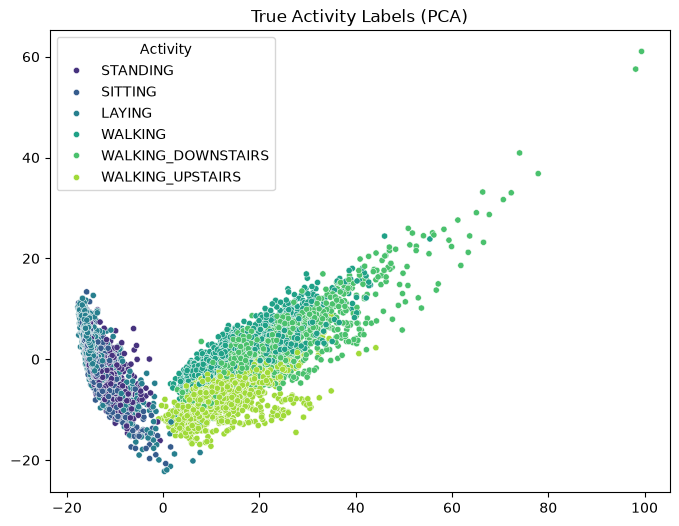

In [15]:
# Apply dimensionality reduction (PCA)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y_true, palette='viridis', s=20)
plt.title('True Activity Labels (PCA)')
plt.savefig('./images/exp8_plot_2.pdf', format='pdf', bbox_inches='tight')
plt.show()



## 3. K-Means with Elbow Method Results




 k  WCSS (Inertia)  Silhouette Score
 2    3.272857e+06          0.393732
 3    2.921079e+06          0.316517
 4    2.792698e+06          0.278265
 5    2.743695e+06          0.259672
 6    2.606467e+06          0.117070
 7    2.550109e+06          0.101209
 8    2.527230e+06          0.091992


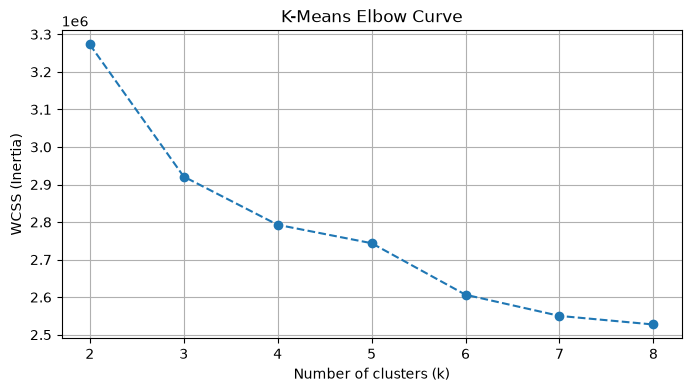

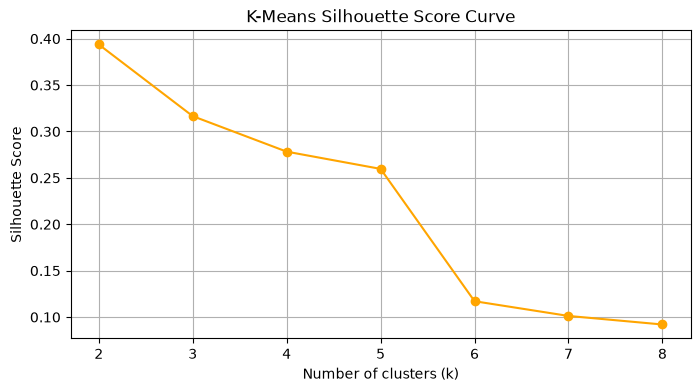

In [16]:
k_values = range(2, 9)
wcss = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, kmeans.labels_))

# Print the elbow method table so results are captured in notebook output
elbow_table = pd.DataFrame({
    'k': list(k_values),
    'WCSS (Inertia)': wcss,
    'Silhouette Score': silhouette_scores
})
print(elbow_table.to_string(index=False))

# Plot Elbow curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, wcss, marker='o', linestyle='--')
plt.title('K-Means Elbow Curve')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.grid(True)
plt.savefig('./images/exp8_plot_3.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Plot Silhouette Score curve
plt.figure(figsize=(8, 4))
plt.plot(k_values, silhouette_scores, marker='o', linestyle='-', color='orange')
plt.title('K-Means Silhouette Score Curve')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.savefig('./images/exp8_plot_4.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Choose optimal K based on elbow/silhouette
optimal_k = 6
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)


## 4. Clustering Implementation (DBSCAN & Hierarchical)




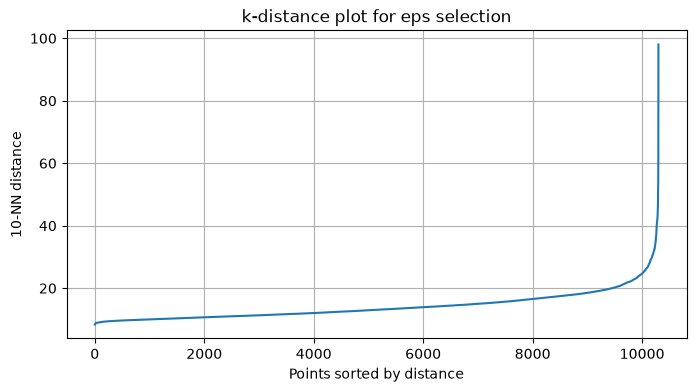

Selected eps (k-distance elbow) = 22.262
DBSCAN found 1 clusters and 282 noise points (2.7% of data)


In [17]:
# DBSCAN Tuning
# eps must be chosen relative to the data's actual distance scale.
# In 561-D standardized space, typical pairwise distances are ~sqrt(561) ~ 23-24,
# so eps=5.0 was far too small and caused DBSCAN to label almost everything as noise
# (or collapse to a single cluster), giving undefined evaluation metrics.
# We instead use a k-distance plot to pick a data-driven eps.
from sklearn.neighbors import NearestNeighbors

min_samples_val = 10
neigh = NearestNeighbors(n_neighbors=min_samples_val)
neigh.fit(X_scaled)
distances, _ = neigh.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(8, 4))
plt.plot(k_distances)
plt.ylabel(f'{min_samples_val}-NN distance')
plt.xlabel('Points sorted by distance')
plt.title('k-distance plot for eps selection')
plt.grid(True)
plt.savefig('./images/exp8_plot_dbscan_kdist.pdf', format='pdf', bbox_inches='tight')
plt.show()

# Pick eps at the 'knee' of the k-distance curve.
# As a robust automatic estimate, use the point of maximum curvature (elbow)
# via the point farthest from the line joining the first and last points.
def find_elbow(y):
    x = np.arange(len(y))
    p1 = np.array([x[0], y[0]])
    p2 = np.array([x[-1], y[-1]])
    line_vec = p2 - p1
    line_vec_norm = line_vec / np.linalg.norm(line_vec)
    vecs = np.column_stack([x, y]) - p1
    proj_len = vecs @ line_vec_norm
    proj = np.outer(proj_len, line_vec_norm)
    dist_to_line = np.linalg.norm(vecs - proj, axis=1)
    return x[np.argmax(dist_to_line)]

elbow_idx = find_elbow(k_distances)
eps_val = k_distances[elbow_idx]
print(f"Selected eps (k-distance elbow) = {eps_val:.3f}")

dbscan = DBSCAN(eps=eps_val, min_samples=min_samples_val)
dbscan_labels = dbscan.fit_predict(X_scaled)

n_clusters_found = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_noise = int((dbscan_labels == -1).sum())
print(f"DBSCAN found {n_clusters_found} clusters and {n_noise} noise points "
      f"({n_noise / len(dbscan_labels):.1%} of data)")

# Hierarchical Agglomerative Clustering
hac = AgglomerativeClustering(n_clusters=optimal_k, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)


## 5. Graphs and Visualizations




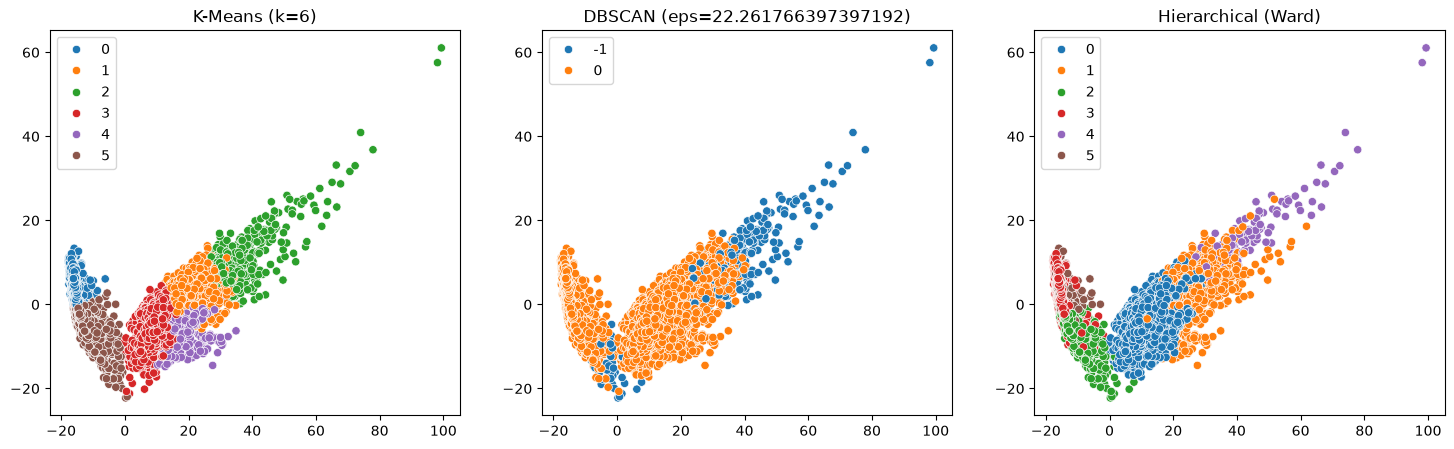

In [18]:
# Visualizing Clusters in 2D (PCA)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', ax=axes[0])
axes[0].set_title(f'K-Means (k={optimal_k})')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=dbscan_labels, palette='tab10', ax=axes[1])
axes[1].set_title(f'DBSCAN (eps={eps_val})')

sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=hac_labels, palette='tab10', ax=axes[2])
axes[2].set_title('Hierarchical (Ward)')

plt.savefig('./images/exp8_plot_5.pdf', format='pdf', bbox_inches='tight')
plt.show()



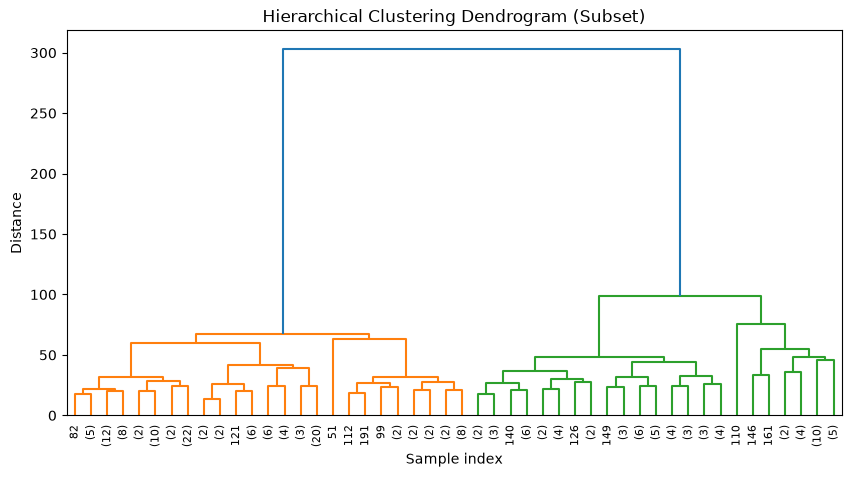

In [19]:
# Dendrogram (using a subset of data for readability)
subset_idx = np.random.choice(range(len(X_scaled)), size=200, replace=False)
X_subset = X_scaled[subset_idx]
linked = linkage(X_subset, method='ward')

plt.figure(figsize=(10, 5))
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Subset)')
plt.xlabel('Sample index')
plt.ylabel('Distance')
plt.savefig('./images/exp8_plot_6.pdf', format='pdf', bbox_inches='tight')
plt.show()



## 6. Evaluation Metrics and Results




,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Adjusted Rand Index (ARI),Normalized Mutual Information (NMI)
K-Means,0.117070,2.525999,2504.685859,0.285064,0.461409
DBSCAN,0.443610,1.599590,714.467084,0.003821,0.024822
Hierarchical,0.117029,2.482039,2349.667698,0.459875,0.601498


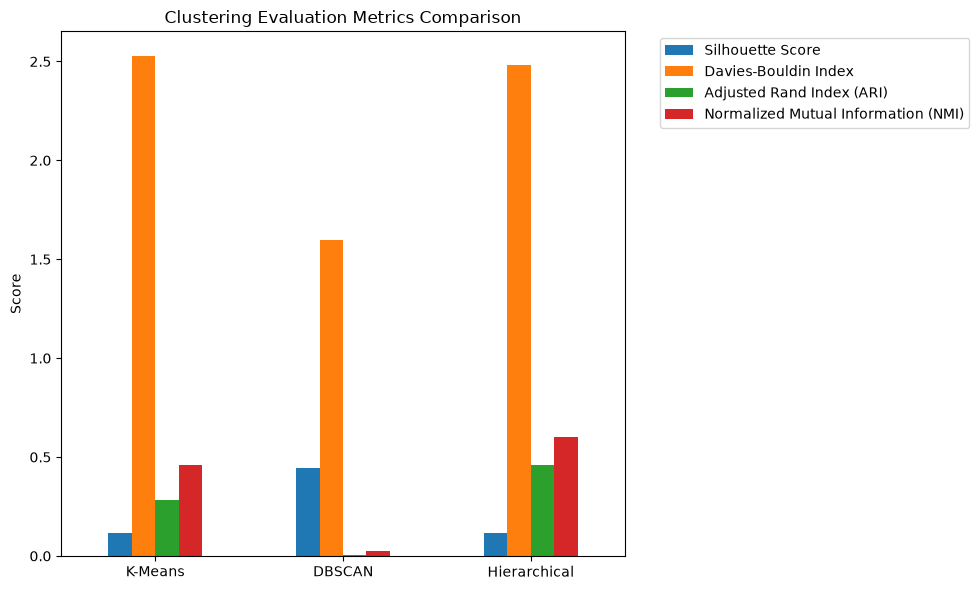

In [20]:
def evaluate_clustering(name, labels):
    # If DBSCAN finds only noise, we return NaNs
    if len(set(labels)) <= 1:
        return [np.nan] * 5
    
    sil = silhouette_score(X_scaled, labels)
    db = davies_bouldin_score(X_scaled, labels)
    ch = calinski_harabasz_score(X_scaled, labels)
    ari = adjusted_rand_score(y_encoded, labels)
    nmi = normalized_mutual_info_score(y_encoded, labels)
    return [sil, db, ch, ari, nmi]

metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Calinski-Harabasz Index', 'Adjusted Rand Index (ARI)', 'Normalized Mutual Information (NMI)']

res_kmeans = evaluate_clustering('K-Means', kmeans_labels)
res_dbscan = evaluate_clustering('DBSCAN', dbscan_labels)
res_hac = evaluate_clustering('Hierarchical', hac_labels)

results_df = pd.DataFrame([res_kmeans, res_dbscan, res_hac], columns=metrics, index=['K-Means', 'DBSCAN', 'Hierarchical'])
display(results_df)

# Plotting metrics (excluding Calinski-Harabasz due to different scale)
plot_metrics = ['Silhouette Score', 'Davies-Bouldin Index', 'Adjusted Rand Index (ARI)', 'Normalized Mutual Information (NMI)']
results_df[plot_metrics].plot(kind='bar', figsize=(10, 6))
plt.title('Clustering Evaluation Metrics Comparison')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('./images/exp8_plot_7.pdf', format='pdf', bbox_inches='tight')
plt.show()



## 7. Observations and Comparative Analysis
- **K-Means**: Shows good partitioning when cluster centers are relatively globular. Sensitive to initialization and choice of k.
- **DBSCAN**: Detects density-based clusters and can label noise points, but highly sensitive to `eps` and `min_samples`, especially in high-dimensional datasets like HAR.
- **Hierarchical**: Creates a hierarchy of clusters without needing a predefined number, but computationally expensive for the full dataset.

